
# 📞  Telecom – Staff Scheduling Optimization

## Phase 2: Implementation Using Gurobi (gurobipy)

---

### Course: Operations Research 2

### Solver: Gurobi

### Programming Language: Python

---

## 👥 Group Members

* **[Bardia Soizi]** – 401104181
* **[Saba Yousefzade]** – 401104576
* **[Mahan Kazemi]** – 401108137
* **[Yekta Nasiri]** – 402104541
---

## 1️⃣ Introduction

In this phase of the project, the mathematical model developed in **Phase 1** is implemented and solved using the **Gurobi optimization solver**.

The objective is to determine the optimal staffing schedule for a telecommunications call center such that:

* total salary cost is minimized,
* service level requirements are respected,
* operator shortages are controlled and penalized appropriately.


---

## 2️⃣ Model Overview (Phase 1 Recap)

The problem is formulated as an **integer linear programming (ILP)** model.

### Indices

* ( i = 0, \dots, 23 ): hour of the day
* ( j = 1,2 ): institutions

  * ( j = 1 ): سرمایه پارسیان
  * ( j = 2 ): مهر ایرانیان

---

### Decision Variables

* ( x_{ij} ): number of operators starting work at hour (i) for institution (j)
* ( L_{ij} ): shortage of operators at hour (i) for institution (j)

All decision variables are **non-negative integers**.

---

## 3️⃣ Parameters

The model uses the following parameters:

* ( C_i ): hourly wage cost for operators starting at hour (i)
* ( D_{ij} ): demand of institution (j) at hour (i)
* ( Q_i ): set of starting hours whose shifts cover hour (i)

Each shift consists of **3 working hours**, **1 rest hour**, and **3 additional working hours**, resulting in **6 active working hours** per shift.

---

## 4️⃣ Objective Function

The objective is to minimize the total operational cost, which consists of:

1. **Total salary cost** of employed operators
2. **Shortage penalties**:

   * Institution 1 (سرمایه پارسیان):

     * 7–17: penalty of 60 units per operator shortage
     * Other hours: penalty of 30 units
   * Institution 2 (مهر ایرانیان):

     * All hours: penalty of 45 units per operator shortage

### Mathematical Form

$$
\min Z =
\sum_{i=0}^{23}\sum_{j=1}^{2} C_i x_{ij}

* 60 \sum_{i=7}^{17} L_{i1}
* 30 \left( \sum_{i=0}^{6} L_{i1} + \sum_{i=18}^{23} L_{i1} \right)
* 45 \sum_{i=0}^{23} L_{i2}
  $$

---

## 5️⃣ Constraints

### 1. Maximum operators starting per hour

At most **100 operators** may start work in any hour:

$$
\sum_{j=1}^{2} x_{ij} \leq 100 \quad \forall i
$$

---

### 2. Maximum concurrent operators

Due to capacity limitations, the number of **simultaneously active operators** may not exceed **420**:

$$
\sum_{h \in Q_i} \sum_{j=1}^{2} x_{hj} \leq 420 \quad \forall i
$$

---

### 3. Demand satisfaction with shortage

Demand may be partially unmet and is captured through shortage variables:

$$
D_{ij} - \sum_{h \in Q_i} x_{hj} \leq L_{ij} \quad \forall i,j
$$

---

### 4. Hourly shortage limit

At most **10 operators** may be missing for each institution in any hour:

$$
L_{ij} \leq 10 \quad \forall i,j
$$

---

### 5. Daily shortage limits

Total daily shortages are bounded as follows:

* Institution 1 (سرمایه پارسیان):
  $$
  \sum_{i=0}^{23} L_{i1} \leq 40
  $$

* Institution 2 (مهر ایرانیان):
  $$
  \sum_{i=0}^{23} L_{i2} \leq 30
  $$

---

### 6. Minimum service level

At least **80 operators** must be active at any hour:

$$
\sum_{h \in Q_i} \sum_{j=1}^{2} x_{hj} \geq 80 \quad \forall i
$$

---

## 6️⃣ Implementation Details

The model is implemented in **Python** using the `gurobipy` library.

Key implementation choices:

* Integer decision variables
* Explicit definition of shift coverage sets (Q_i)
* Use of `addVars` and `addConstrs` for clarity and efficiency

The full implementation code is provided in the following cells.


## 1️⃣ Import required libraries


In [82]:
import gurobipy as gp
from gurobipy import GRB

---

## 2️⃣ Define sets

* **HOURS**: hours of the day ( i = 0,\dots,23 )
* **COMPANIES**:

  * 1 → سرمایه پارسیان
  * 2 → مهر ایرانیان

In [83]:
HOURS = range(24)
COMPANIES = [1, 2]

---

## 3️⃣ Define parameters

### Hourly salary cost (same for both companies)


In [84]:
COST = {
    0:189, 1:189, 2:189, 3:180, 4:171, 5:162, 6:153,
    7:144, 8:135, 9:126, 10:126, 11:135, 12:144, 13:153,
    14:162, 15:171, 16:180, 17:189, 18:189, 19:189,
    20:189, 21:189, 22:189, 23:189
}

---

### Demand ( D_{ij} )


In [85]:
DEMAND = {
    (0,1):120, (0,2):70,   (1,1):95,  (1,2):40,
    (2,1):90,  (2,2):20,  (3,1):50,  (3,2):30,
    (4,1):30,  (4,2):50,  (5,1):30,  (5,2):40,
    (6,1):60,  (6,2):40,  (7,1):110, (7,2):90,
    (8,1):140, (8,2):110, (9,1):200, (9,2):110,
    (10,1):180,(10,2):110,(11,1):180,(11,2):130,
    (12,1):240,(12,2):150,(13,1):220,(13,2):160,
    (14,1):220,(14,2):120,(15,1):230,(15,2):130,
    (16,1):250,(16,2):160,(17,1):260,(17,2):180,
    (18,1):230,(18,2):200,(19,1):250,(19,2):170,
    (20,1):260,(20,2):140,(21,1):250,(21,2):110,
    (22,1):220,(22,2):100,(23,1):190,(23,2):90
}

---

### Shift coverage sets ( Q_i )

Each shift has **6 active working hours** (3 work + 1 rest + 3 work).

In [86]:
Q = {
    0:[18,19,20,22,23,0],   1:[19,20,21,23,0,1],
    2:[20,21,22,0,1,2],    3:[21,22,23,1,2,3],
    4:[22,23,0,2,3,4],     5:[23,0,1,3,4,5],
    6:[0,1,2,4,5,6],       7:[1,2,3,5,6,7],
    8:[2,3,4,6,7,8],       9:[3,4,5,7,8,9],
    10:[4,5,6,8,9,10],     11:[5,6,7,9,10,11],
    12:[6,7,8,10,11,12],   13:[7,8,9,11,12,13],
    14:[8,9,10,12,13,14],  15:[9,10,11,13,14,15],
    16:[10,11,12,14,15,16],17:[11,12,13,15,16,17],
    18:[12,13,14,16,17,18],19:[13,14,15,17,18,19],
    20:[14,15,16,18,19,20],21:[15,16,17,19,20,21],
    22:[16,17,18,20,21,22],23:[17,18,19,21,22,23]
}

---

## 4️⃣ Create the optimization model

In [87]:
model = gp.Model("Telecom_Staff_Scheduling")

--

## 5️⃣ Define decision variables


* ( x_{ij} ): number of operators starting at hour *i* for company *j*
* ( L_{ij} ): shortage of operators at hour *i* for company *j*

In [88]:


x = model.addVars(HOURS, COMPANIES, vtype=GRB.INTEGER, name="x")
L = model.addVars(HOURS, COMPANIES, vtype=GRB.INTEGER, name="L")

---

## 6️⃣ Objective function

The objective minimizes:

* total salary cost
* shortage penalties for both companies

In [89]:
model.setObjective(
    gp.quicksum(x[i,j] * COST[i] for i in HOURS for j in COMPANIES)
    + 60 * gp.quicksum(L[i,1] for i in range(7,18))
    + 30 * (gp.quicksum(L[i,1] for i in range(0,7))
           + gp.quicksum(L[i,1] for i in range(18,24)))
    + 45 * gp.quicksum(L[i,2] for i in HOURS),
    GRB.MINIMIZE
)

---

## 7️⃣ Constraints

### Maximum 100 operators starting per hour

In [90]:
model.addConstrs(
    (gp.quicksum(x[i,j] for j in COMPANIES) <= 100 for i in HOURS)
)

{0: <gurobi.Constr *Awaiting Model Update*>,
 1: <gurobi.Constr *Awaiting Model Update*>,
 2: <gurobi.Constr *Awaiting Model Update*>,
 3: <gurobi.Constr *Awaiting Model Update*>,
 4: <gurobi.Constr *Awaiting Model Update*>,
 5: <gurobi.Constr *Awaiting Model Update*>,
 6: <gurobi.Constr *Awaiting Model Update*>,
 7: <gurobi.Constr *Awaiting Model Update*>,
 8: <gurobi.Constr *Awaiting Model Update*>,
 9: <gurobi.Constr *Awaiting Model Update*>,
 10: <gurobi.Constr *Awaiting Model Update*>,
 11: <gurobi.Constr *Awaiting Model Update*>,
 12: <gurobi.Constr *Awaiting Model Update*>,
 13: <gurobi.Constr *Awaiting Model Update*>,
 14: <gurobi.Constr *Awaiting Model Update*>,
 15: <gurobi.Constr *Awaiting Model Update*>,
 16: <gurobi.Constr *Awaiting Model Update*>,
 17: <gurobi.Constr *Awaiting Model Update*>,
 18: <gurobi.Constr *Awaiting Model Update*>,
 19: <gurobi.Constr *Awaiting Model Update*>,
 20: <gurobi.Constr *Awaiting Model Update*>,
 21: <gurobi.Constr *Awaiting Model Update*>

### Maximum 420 concurrent operators


In [91]:
model.addConstrs(
    (gp.quicksum(x[h,j] for h in Q[i] for j in COMPANIES) <= 420 for i in HOURS)
)

{0: <gurobi.Constr *Awaiting Model Update*>,
 1: <gurobi.Constr *Awaiting Model Update*>,
 2: <gurobi.Constr *Awaiting Model Update*>,
 3: <gurobi.Constr *Awaiting Model Update*>,
 4: <gurobi.Constr *Awaiting Model Update*>,
 5: <gurobi.Constr *Awaiting Model Update*>,
 6: <gurobi.Constr *Awaiting Model Update*>,
 7: <gurobi.Constr *Awaiting Model Update*>,
 8: <gurobi.Constr *Awaiting Model Update*>,
 9: <gurobi.Constr *Awaiting Model Update*>,
 10: <gurobi.Constr *Awaiting Model Update*>,
 11: <gurobi.Constr *Awaiting Model Update*>,
 12: <gurobi.Constr *Awaiting Model Update*>,
 13: <gurobi.Constr *Awaiting Model Update*>,
 14: <gurobi.Constr *Awaiting Model Update*>,
 15: <gurobi.Constr *Awaiting Model Update*>,
 16: <gurobi.Constr *Awaiting Model Update*>,
 17: <gurobi.Constr *Awaiting Model Update*>,
 18: <gurobi.Constr *Awaiting Model Update*>,
 19: <gurobi.Constr *Awaiting Model Update*>,
 20: <gurobi.Constr *Awaiting Model Update*>,
 21: <gurobi.Constr *Awaiting Model Update*>

---

### Demand satisfaction with shortage


In [92]:
model.addConstrs(
    (DEMAND[i,j] - gp.quicksum(x[h,j] for h in Q[i]) <= L[i,j]
     for i in HOURS for j in COMPANIES)
)

{(0, 1): <gurobi.Constr *Awaiting Model Update*>,
 (0, 2): <gurobi.Constr *Awaiting Model Update*>,
 (1, 1): <gurobi.Constr *Awaiting Model Update*>,
 (1, 2): <gurobi.Constr *Awaiting Model Update*>,
 (2, 1): <gurobi.Constr *Awaiting Model Update*>,
 (2, 2): <gurobi.Constr *Awaiting Model Update*>,
 (3, 1): <gurobi.Constr *Awaiting Model Update*>,
 (3, 2): <gurobi.Constr *Awaiting Model Update*>,
 (4, 1): <gurobi.Constr *Awaiting Model Update*>,
 (4, 2): <gurobi.Constr *Awaiting Model Update*>,
 (5, 1): <gurobi.Constr *Awaiting Model Update*>,
 (5, 2): <gurobi.Constr *Awaiting Model Update*>,
 (6, 1): <gurobi.Constr *Awaiting Model Update*>,
 (6, 2): <gurobi.Constr *Awaiting Model Update*>,
 (7, 1): <gurobi.Constr *Awaiting Model Update*>,
 (7, 2): <gurobi.Constr *Awaiting Model Update*>,
 (8, 1): <gurobi.Constr *Awaiting Model Update*>,
 (8, 2): <gurobi.Constr *Awaiting Model Update*>,
 (9, 1): <gurobi.Constr *Awaiting Model Update*>,
 (9, 2): <gurobi.Constr *Awaiting Model Update*>,


---

### Shortage limits


In [93]:
model.addConstrs(
    (L[i,j] <= 10 for i in HOURS for j in COMPANIES)
)

model.addConstr(gp.quicksum(L[i,1] for i in HOURS) <= 40)
model.addConstr(gp.quicksum(L[i,2] for i in HOURS) <= 30)

<gurobi.Constr *Awaiting Model Update*>

### Minimum service level


In [94]:
model.addConstrs(
    (gp.quicksum(x[h,j] for h in Q[i] for j in COMPANIES) >= 80 for i in HOURS)
)

{0: <gurobi.Constr *Awaiting Model Update*>,
 1: <gurobi.Constr *Awaiting Model Update*>,
 2: <gurobi.Constr *Awaiting Model Update*>,
 3: <gurobi.Constr *Awaiting Model Update*>,
 4: <gurobi.Constr *Awaiting Model Update*>,
 5: <gurobi.Constr *Awaiting Model Update*>,
 6: <gurobi.Constr *Awaiting Model Update*>,
 7: <gurobi.Constr *Awaiting Model Update*>,
 8: <gurobi.Constr *Awaiting Model Update*>,
 9: <gurobi.Constr *Awaiting Model Update*>,
 10: <gurobi.Constr *Awaiting Model Update*>,
 11: <gurobi.Constr *Awaiting Model Update*>,
 12: <gurobi.Constr *Awaiting Model Update*>,
 13: <gurobi.Constr *Awaiting Model Update*>,
 14: <gurobi.Constr *Awaiting Model Update*>,
 15: <gurobi.Constr *Awaiting Model Update*>,
 16: <gurobi.Constr *Awaiting Model Update*>,
 17: <gurobi.Constr *Awaiting Model Update*>,
 18: <gurobi.Constr *Awaiting Model Update*>,
 19: <gurobi.Constr *Awaiting Model Update*>,
 20: <gurobi.Constr *Awaiting Model Update*>,
 21: <gurobi.Constr *Awaiting Model Update*>

## 8️⃣ Solve the model

In [95]:
model.optimize()


Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) 7 150U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 170 rows, 96 columns and 1056 nonzeros (Min)
Model fingerprint: 0xafeb22ae
Model has 96 linear objective coefficients
Variable types: 0 continuous, 96 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+01, 2e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+01, 4e+02]
Found heuristic solution: objective 207330.00000
Presolve removed 48 rows and 0 columns
Presolve time: 0.00s
Presolved: 122 rows, 96 columns, 1008 nonzeros
Variable types: 0 continuous, 96 integer (0 binary)

Root relaxation: objective 1.848117e+05, 87 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent

## 9️⃣ Display results

In [96]:
if model.status == GRB.OPTIMAL:
    print(f"Optimal objective value: {model.objVal:,.0f}")

    print("\nActive operators:")
    for i in HOURS:
        for j in COMPANIES:
            if x[i,j].X > 0:
                print(f"x[{i},{j}] = {int(x[i,j].X)}")

    print("\nShortages:")
    for i in HOURS:
        for j in COMPANIES:
            if L[i,j].X > 0:
                print(f"L[{i},{j}] = {int(L[i,j].X)}")

Optimal objective value: 184,848

Active operators:
x[0,1] = 6
x[0,2] = 4
x[1,2] = 3
x[3,2] = 14
x[4,2] = 22
x[5,1] = 31
x[6,1] = 23
x[6,2] = 30
x[7,1] = 56
x[7,2] = 43
x[8,1] = 61
x[8,2] = 1
x[9,1] = 52
x[9,2] = 30
x[10,1] = 13
x[10,2] = 27
x[11,1] = 44
x[12,1] = 43
x[12,2] = 49
x[13,2] = 37
x[14,1] = 51
x[14,2] = 21
x[15,1] = 70
x[15,2] = 30
x[16,1] = 30
x[16,2] = 33
x[17,1] = 63
x[17,2] = 21
x[18,1] = 39
x[18,2] = 33
x[19,1] = 27
x[19,2] = 23
x[20,1] = 33
x[21,1] = 27
x[21,2] = 3
x[22,1] = 24
x[22,2] = 10

Shortages:
L[1,1] = 2
L[1,2] = 7
L[17,1] = 10
L[17,2] = 10
L[18,1] = 4
L[18,2] = 6
L[19,2] = 5
L[20,1] = 10
L[22,1] = 4
L[23,1] = 10


---
# Sensitivity Analysis for Gurobi Model

This notebook performs sensitivity analysis for:

1. **Objective function coefficients** (allowable increase/decrease for active variables).  
2. **Constraint RHS values** (allowable increase/decrease for constraints).  

> Note: For **integer/binary variables**, we will compute these values on the **LP relaxation** since Gurubi has no Option for MILP.




---

## Prepare LP Relaxation (for MIPs)


In [97]:

from gurobipy import GRB

# Save original variable types
original_vtypes = {v.VarName: v.VType for v in model.getVars()}

# Relax all integer/binary variables to continuous
for v in model.getVars():
    if v.VType != GRB.CONTINUOUS:
        v.VType = GRB.CONTINUOUS

# Solve LP relaxation
model.optimize()


Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) 7 150U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 170 rows, 96 columns and 1056 nonzeros (Min)
Model fingerprint: 0xc4744cc0
Model has 96 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+01, 2e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+01, 4e+02]
Presolve removed 72 rows and 0 columns
Presolve time: 0.01s
Presolved: 98 rows, 120 columns, 744 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   1.071875e+03   0.000000e+00      0s
      73    1.8481167e+05   0.000000e+00   0.000000e+00      0s

Solved in 73 iterations and 0.02 seconds (0.00 work units)
Optimal objective  1.848116667e+05



---

##  Sensitivity Analysis: Objective Coefficients

# Objective Function Coefficient Sensitivity

For each **active variable** (X > 0), we print:

- Current coefficient
- Allowable decrease (`SAObjLow`)
- Allowable increase (`SAObjUp`)
- Valid range for the coefficient
```


In [98]:

import pandas as pd

obj_sensitivity = []

print("\n========== Objective Coefficient Sensitivity ==========\n")

for v in model.getVars():
    if v.X > 0:  # active variables
        if hasattr(v, 'SAObjLow') and hasattr(v, 'SAObjUp'):
            print(f"Variable: {v.VarName}")
            print(f"  Current coefficient : {v.Obj}")
            print(f"  Allowable decrease  : {v.SAObjLow}")
            print(f"  Allowable increase  : {v.SAObjUp}")
            print(f"  Valid range         : [{v.SAObjLow}, {v.SAObjUp}]")
            obj_sensitivity.append([v.VarName, v.Obj, v.SAObjLow, v.SAObjUp])
        else:
            print(f"Variable: {v.VarName} - Sensitivity info not available")
        print("-" * 55)

# Export to pandas table
df_obj = pd.DataFrame(
    obj_sensitivity,
    columns=["Variable", "Current Obj", "SAObjLow", "SAObjUp"]
)

display(df_obj)



========== Objective Coefficient Sensitivity ==========

Variable: x[0,1]
  Current coefficient : 189.0
  Allowable decrease  : 188.99999999999997
  Allowable increase  : 189.00000000000006
  Valid range         : [188.99999999999997, 189.00000000000006]
-------------------------------------------------------
Variable: x[0,2]
  Current coefficient : 189.0
  Allowable decrease  : 189.0
  Allowable increase  : 189.0
  Valid range         : [189.0, 189.0]
-------------------------------------------------------
Variable: x[1,2]
  Current coefficient : 189.0
  Allowable decrease  : 188.99999999999991
  Allowable increase  : 189.0
  Valid range         : [188.99999999999991, 189.0]
-------------------------------------------------------
Variable: x[3,1]
  Current coefficient : 180.0
  Allowable decrease  : 180.0
  Allowable increase  : 180.0
  Valid range         : [180.0, 180.0]
-------------------------------------------------------
Variable: x[3,2]
  Current coefficient : 180.0
  Allowab

,Variable,Current Obj,SAObjLow,SAObjUp
0,"x[0,1]",189.0,189.000000,189.0
1,"x[0,2]",189.0,189.000000,189.0
2,"x[1,2]",189.0,189.000000,189.0
3,"x[3,1]",180.0,180.000000,180.0
4,"x[3,2]",180.0,180.000000,180.0
5,"x[4,2]",171.0,171.000000,171.0
6,"x[5,1]",162.0,162.000000,162.0
7,"x[6,1]",153.0,153.000000,153.0
8,"x[6,2]",153.0,153.000000,153.0
9,"x[7,1]",144.0,144.000000,144.0




---

##  Sensitivity Analysis: RHS of Constraints

# RHS Constraint Sensitivity

For each constraint, we print:

- Current RHS
- Allowable decrease (`SARHSLow`)
- Allowable increase (`SARHSUp`)
- Valid RHS range


In [99]:

rhs_sensitivity = []

print("\n========== RHS Constraint Sensitivity ==========\n")

for c in model.getConstrs():
    if hasattr(c, 'SARHSLow') and hasattr(c, 'SARHSUp'):
        print(f"Constraint: {c.ConstrName}")
        print(f"  Current RHS        : {c.RHS}")
        print(f"  Allowable decrease : {c.SARHSLow}")
        print(f"  Allowable increase : {c.SARHSUp}")
        print(f"  Valid RHS range    : [{c.SARHSLow}, {c.SARHSUp}]")
        rhs_sensitivity.append([c.ConstrName, c.RHS, c.SARHSLow, c.SARHSUp])
    else:
        print(f"Constraint: {c.ConstrName} - Sensitivity info not available")
    print("-" * 55)

# Export to pandas table
df_rhs = pd.DataFrame(
    rhs_sensitivity,
    columns=["Constraint", "Current RHS", "SARHSLow", "SARHSUp"]
)

display(df_rhs)



========== RHS Constraint Sensitivity ==========

Constraint: R0
  Current RHS        : 100.0
  Allowable decrease : 8.20987654320983
  Allowable increase : inf
  Valid RHS range    : [8.20987654320983, inf]
-------------------------------------------------------
Constraint: R1
  Current RHS        : 100.0
  Allowable decrease : 4.382716049382708
  Allowable increase : inf
  Valid RHS range    : [4.382716049382708, inf]
-------------------------------------------------------
Constraint: R2
  Current RHS        : 100.0
  Allowable decrease : 0.0
  Allowable increase : inf
  Valid RHS range    : [0.0, inf]
-------------------------------------------------------
Constraint: R3
  Current RHS        : 100.0
  Allowable decrease : 12.592592592592524
  Allowable increase : inf
  Valid RHS range    : [12.592592592592524, inf]
-------------------------------------------------------
Constraint: R4
  Current RHS        : 100.0
  Allowable decrease : 22.09876543209873
  Allowable increase : inf
 

,Constraint,Current RHS,SARHSLow,SARHSUp
0,R0,100.0,8.209877,inf
1,R1,100.0,4.382716,inf
2,R2,100.0,0.000000,inf
3,R3,100.0,12.592593,inf
4,R4,100.0,22.098765,inf
...,...,...,...,...
165,R165,80.0,-inf,415.617284
166,R166,80.0,-inf,390.000000
167,R167,80.0,-inf,360.000000
168,R168,80.0,-inf,316.666667



---

##  Restore Original MIP and Re-Optimize
```


In [100]:

# Restore original variable types
for v in model.getVars():
    v.VType = original_vtypes[v.VarName]

# Re-optimize original MIP
model.optimize()

Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) 7 150U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 170 rows, 96 columns and 1056 nonzeros (Min)
Model fingerprint: 0xafeb22ae
Model has 96 linear objective coefficients
Variable types: 0 continuous, 96 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+01, 2e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+01, 4e+02]

Loaded MIP start from previous solve with objective 184848

Presolve removed 48 rows and 0 columns
Presolve time: 0.00s
Presolved: 122 rows, 96 columns, 1008 nonzeros
Variable types: 0 continuous, 96 integer (0 binary)

Root relaxation: objective 1.848117e+05, 87 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf

# Effect of Changing Objective Coefficient and RHS
now we will:
1. Pick **one variable's objective coefficient** and **one constraint's RHS**.
2. Vary them within reasonable ranges.
3. Re-optimize the model for each variation.
4. Plot the resulting **objective function values** to see the impact.

This helps visualize how sensitive the optimal solution is to changes in key parameters.


In [ ]:
var_to_vary = x[8,1]      
constr_to_vary = model.getConstrs()[0]  


We chose:

- **Objective coefficient**: `x[8,1]`  
- **Constraint RHS**: first constraint (`hour 0 max 100 operators`)  



---
### Define variation ranges

In [103]:
import numpy as np

# Current coefficient and RHS
orig_coef = var_to_vary.Obj
orig_rhs = constr_to_vary.RHS

# Define ranges: ±50% for coefficient, ±20% for RHS
coef_range = np.linspace(orig_coef*0.5, orig_coef*1.5, 10)
rhs_range = np.linspace(orig_rhs*0.8, orig_rhs*1.2, 10)


### Effect of changing the objective coefficient

In [104]:
obj_values_coef = []

for coef in coef_range:
    var_to_vary.Obj = coef
    model.optimize()
    if model.status == GRB.OPTIMAL:
        obj_values_coef.append(model.objVal)
    else:
        obj_values_coef.append(np.nan)

# Restore original coefficient
var_to_vary.Obj = orig_coef


Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) 7 150U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 170 rows, 96 columns and 1056 nonzeros (Min)
Model fingerprint: 0x91ef82cc
Model has 96 linear objective coefficients
Variable types: 0 continuous, 96 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+01, 2e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+01, 4e+02]

Loaded MIP start from previous solve with objective 180731

Presolve removed 48 rows and 0 columns
Presolve time: 0.00s
Presolved: 122 rows, 96 columns, 1008 nonzeros
Variable types: 0 continuous, 96 integer (0 binary)

Root relaxation: objective 1.788150e+05, 73 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf

###  Plot objective vs coefficient

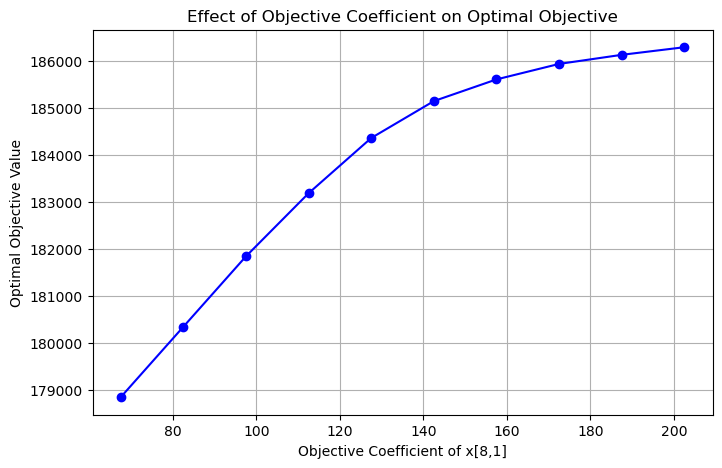

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(coef_range, obj_values_coef, marker='o', color='blue')
plt.xlabel(f"Objective Coefficient of {var_to_vary.VarName}")
plt.ylabel("Optimal Objective Value")
plt.title("Effect of Objective Coefficient on Optimal Objective")
plt.grid(True)
plt.show()


### Effect of changing the RHS

In [106]:
obj_values_rhs = []

for rhs in rhs_range:
    constr_to_vary.RHS = rhs
    model.optimize()
    if model.status == GRB.OPTIMAL:
        obj_values_rhs.append(model.objVal)
    else:
        obj_values_rhs.append(np.nan)

# Restore original RHS
constr_to_vary.RHS = orig_rhs

Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) 7 150U, instruction set [SSE2|AVX|AVX2]
Thread count: 10 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 170 rows, 96 columns and 1056 nonzeros (Min)
Model fingerprint: 0x631040f8
Model has 96 linear objective coefficients
Variable types: 0 continuous, 96 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e+01, 2e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+01, 4e+02]

Loaded MIP start from previous solve with objective 185964

Presolve removed 48 rows and 0 columns
Presolve time: 0.00s
Presolved: 122 rows, 96 columns, 1008 nonzeros
Variable types: 0 continuous, 96 integer (0 binary)

Root relaxation: objective 1.848117e+05, 87 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf

### Plot objective vs RHS

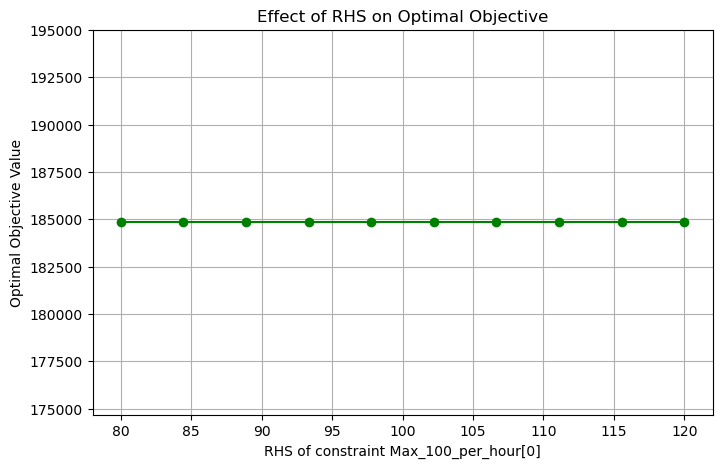

In [107]:
plt.figure(figsize=(8,5))
plt.plot(rhs_range, obj_values_rhs, marker='o', color='green')
plt.xlabel(f"RHS of constraint {constr_to_vary.ConstrName}")
plt.ylabel("Optimal Objective Value")
plt.title("Effect of RHS on Optimal Objective")
plt.grid(True)
plt.show()
